In [1]:
"""
@author: SANJANA RANI
"""

#-------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import math


#AIRCRAFT DATA
#The aircraft considered for this project is AIRBUS A320
#all units are in SI units

b = 35.8                #wing span (m)
s = 122.6                 #wing area (m^2)
u_inf = 248             #cruise velocity (m/s) 
rho = 0.310828          #air density at 11000 m altitude (kg/m^3)
weight = 765180         #aircraft weight (kg) 
wingtaper = 0.266           #wing taper ratio

n = 51                  #number of spanwise stations
a0 = 2*np.pi            #lift curve slope

#DERIVED DATA
L = weight # for cruise condtion lift = Weight.
Cl = L / (0.5*rho*(u_inf**2)*s)
print(f"Lift coefficient C_l based on weight of aircraft: {Cl:.3f}")

# chord distribution
AR = pow(b,2)/s                 #aspect ratio
c_mean = s/b                 #mean aerodynamic chord (m)
lambda_factor = (1-wingtaper)/(1+wingtaper)     #taper ratio factor
print(f"Aspect Ratio AR: {AR:.3f}")
print(f"Mean Aerodynamic Chord (m): {c_mean:.3f}")
print(f"Taper Ratio Factor lambda: {lambda_factor:.3f}")

Lift coefficient C_l based on weight of aircraft: 0.653
Aspect Ratio AR: 10.454
Mean Aerodynamic Chord (m): 3.425
Taper Ratio Factor lambda: 0.580


In [2]:
chord = np.zeros(n)                       #chord distribution array
y = np.linspace(-b/2,b/2,n)               #spanwise stations array
x = np.linspace(-b/2,b/2,n)               #spanwise stations array  
eps = 1e-6
theta = np.linspace(eps, np.pi - eps, n)


eta = np.cos(theta)            #nondimensional spanwise stations array
c = c_mean * ((1 + lambda_factor) - 2*lambda_factor*np.abs(eta))  #chord distribution formula

N = np.arange(1, n+1, 2)        #odd numbers array
Nmodes = len(N)
A = np.zeros((n, Nmodes))            #matrix A initialization
B = np.zeros((n))            #matrix B initialization

Z = (a0/(4*b))                  #constant Z
for i in range(n):
    for j in range(Nmodes):
        A[i, j] = (
            np.sin(N[j]*theta[i]) +
            (a0*c[i]/(4*b)) *
            (N[j]*np.sin(N[j]*theta[i]) / np.sin(theta[i]))
        )
    B[i] = (a0*c[i]) / (2*b)

# ------------------------------------------------
# SOLVE FOR bn COEFFICIENTS
# ------------------------------------------------
bn, *_ = np.linalg.lstsq(A, B, rcond=None)

# ------------------------------------------------
# WING LIFT SLOPE (Finite wing)
# ------------------------------------------------
lift_slope = a0 / (1 + a0/(np.pi*AR))
alpha_w = Cl / lift_slope   # radians
print(f"Wing Lift slope a_0: {lift_slope:.3f} per rad")
print(f"Angle of attack αw = {np.degrees(alpha_w):.3f} deg")

Wing Lift slope a_0: 5.274 per rad
Angle of attack αw = 7.093 deg


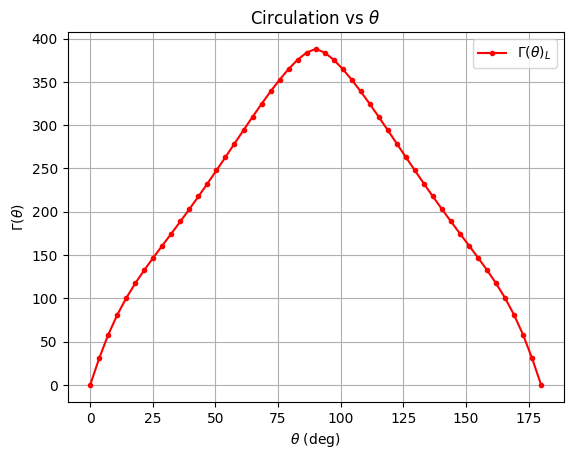

In [3]:
# ------------------------------------------------
# CIRCULATION DISTRIBUTION Γ(θ)
# ------------------------------------------------
Gamma = np.zeros(n)

for i in range(n):
    summation = 0.0
    for j in range(Nmodes):
        summation += bn[j] * np.sin(N[j]*theta[i])
    Gamma[i] = u_inf * b * alpha_w * summation


fig, ax = plt.subplots()

ax.plot(np.rad2deg(theta), Gamma, 'r.-',
        label=r'$\Gamma(\theta)_L$')

ax.set_xlabel(r'$\theta$ (deg)')
ax.set_ylabel(r'$\Gamma(\theta)$')
ax.set_title(r'Circulation vs $\theta$')
ax.grid(True)
ax.legend()

plt.show()


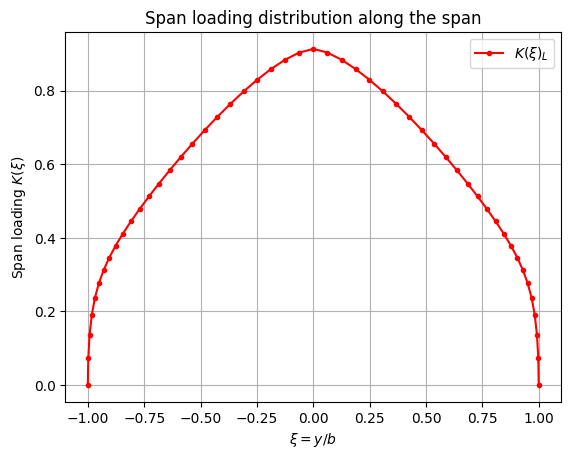

In [4]:
# ------------------------------------------------
# SPAN LOADING K(ξ)
# ------------------------------------------------
K = np.zeros(n)

for i in range(n):
    summation = 0.0
    for j in range(Nmodes):
        summation += bn[j] * np.sin(N[j]*theta[i])
    K[i] = 2 * AR * alpha_w * summation


### span loading
fig, ax = plt.subplots()

ax.plot(eta, K, '.-r', label=r'$K(\xi)_L$')

ax.set_xlabel(r'$\xi = y/b$')
ax.set_ylabel(r'Span loading $K(\xi)$')
ax.set_title('Span loading distribution along the span')
ax.grid(True)
ax.legend()

plt.show()


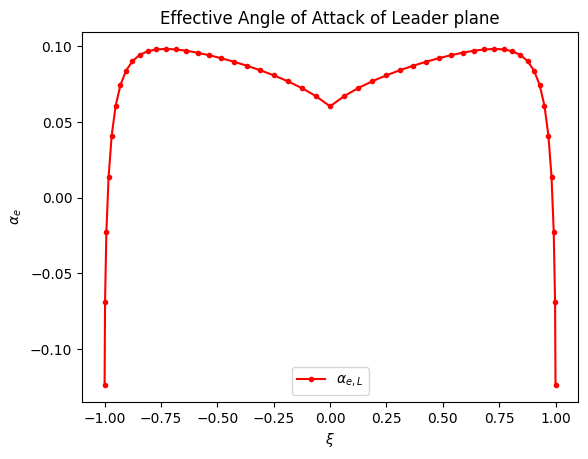

In [5]:
# ------------------------------------------------
# DOWNWASH / INDUCED ANGLE α_i(θ)
# ------------------------------------------------
alpha_induced = np.zeros(n)

for i in range(n):
    summation = 0.0
    for j in range(Nmodes):
        summation += N[j] * bn[j] * np.sin(N[j] * theta[i])
    alpha_induced[i] = alpha_w * summation / np.sin(theta[i])

# ------------------------------------------------
# EFFECTIVE ANGLE OF ATTACK α_e(θ)
# ------------------------------------------------
alpha_effective = alpha_w - alpha_induced

### alpha effective
fig, ax = plt.subplots()
ax.plot((eta),alpha_effective, ".-r", label='$\\alpha_{e,L}$')
ax.set_xlabel('$\\xi$')
ax.set_ylabel('$\\alpha_e$')
ax.set_title('Effective Angle of Attack of Leader plane')
ax.legend()

In [6]:
# ------------------------------------------------
# INDUCED DRAG COEFFICIENT (PLL – normalized form)
# ------------------------------------------------
summation = 0.0

for j in range(Nmodes):
    summation += N[j] * (bn[j] / bn[0])**2

CDi = ((np.pi/4) * AR) * (Cl / ((np.pi/2) * AR))**2 * summation

print(f"Induced Drag Coefficient CDi = {CDi:.6f}")


Induced Drag Coefficient CDi = 0.013265


In [7]:
e = Cl**2 / (np.pi * AR * CDi)
print(f"Oswald efficiency e = {e:.3f}")

Oswald efficiency e = 0.979


In [8]:
# ------------------------------------------------
# FAR-WAKE PARAMETERS: Γ0, s_factor = b0/b, rc/b
# ------------------------------------------------

# index at midspan (y = 0 ↔ θ = 90° for symmetric discretization)
mid = n // 2               # for n = 51 → 25
# index corresponding to theta = pi/2 (midspan)
mid_idx = np.argmin(np.abs(theta - np.pi/2))

# Γ₀ = Γ at wing center (θ = π/2)
Gamma0 = Gamma[mid_idx]
print(f"Gamma0 / (U_inf * b) = {Gamma0 / (u_inf * b):.3f}")
 
dtheta = theta[1] - theta[0]  # theta already in radians

I_half = 0.0
for i in range(mid_idx, len(theta)):
    I_half += Gamma[i] * (b/2) * np.sin(theta[i]) * dtheta

y0 = I_half / Gamma0
b0 = 2 * y0
s_factor = b0 / b   # NOTE: renamed from "s" to avoid clobbering the wing area "s" (=122.6 m^2)
                     # defined in the first cell; that name collision was silently corrupting
                     # every later drag-coefficient computation that divides by wing area.

print(f"y0 = {y0:.3f}")
print(f"b0 = {b0:.3f}")
print(f"s_factor = b0/b = {s_factor:.3f}")



# ------------------------------------------------
# CORE RADIUS rc FROM ENERGY CONSERVATION
# ------------------------------------------------
# Oswald efficiency (you should already have this from CDi)
# e = oswald  # just an alias for clarity
e = e
E0 = (s_factor**2/e)*(2/np.pi)*(Gamma0**2)
power = (((2*np.pi*E0)/(Gamma0**2)) + 0.5)
e_to_the_x = math.exp(power)
rc = b0/ e_to_the_x
print(f"rc/b: {rc/b:.3f}")


Gamma0 / (U_inf * b) = 0.044
y0 = 13.250
b0 = 26.499
s_factor = b0/b = 0.740
rc/b: 0.048


<>:21: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:21: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
/var/folders/y4/vhllsfz10szd65q7tflb2pf40000gn/T/ipykernel_16606/2674625791.py:21: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  ax.plot(y/b0, U_total, '.-r', label='$w_v / U_\infty$')


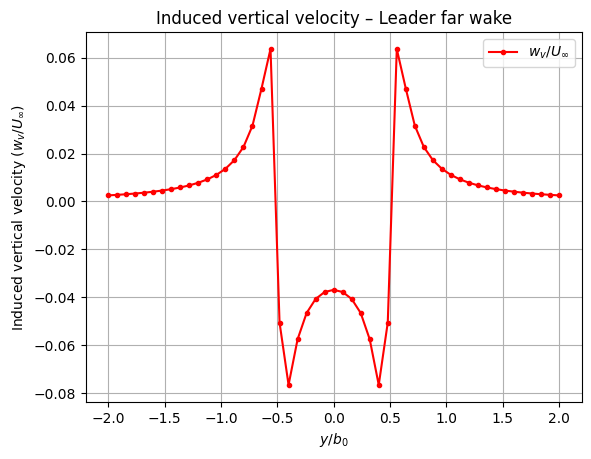

In [9]:
m = 51  # discretization points

# spanwise line through vortex centers
y = np.linspace(-2*b0, 2*b0, m)

# distances from each vortex center
r_right = y - ( b0/2)
r_left  = y - (-b0/2)

# Burnham–Hallock induced velocities
U_right =  (Gamma0 / (2*np.pi)) * (r_right / (r_right**2 + rc**2))
U_left  = -(Gamma0 / (2*np.pi)) * (r_left  / (r_left**2  + rc**2))

# total induced vertical velocity (non-dimensional)
U_total = (U_left + U_right) / u_inf

# ------------------------------------------------
# PLOT
# ------------------------------------------------
fig, ax = plt.subplots()
ax.plot(y/b0, U_total, '.-r', label='$w_v / U_\infty$')
ax.set_xlabel(r'$y / b_0$')
ax.set_ylabel(r'Induced vertical velocity ($w_v / U_\infty$)')
ax.set_title('Induced vertical velocity – Leader far wake')
ax.grid(True)
ax.legend()
plt.show()


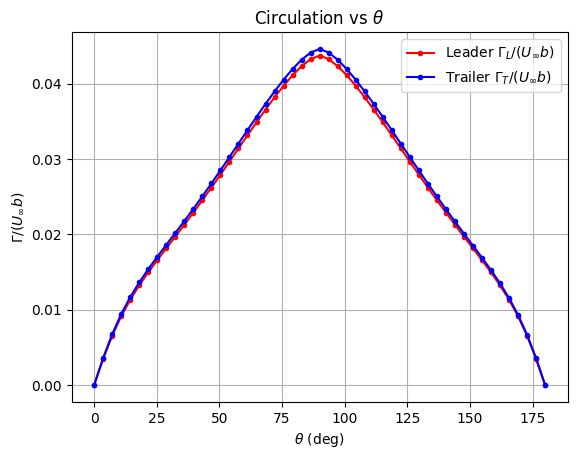

In [10]:
##### Untrimmed Trailing Plane #####

N2 = np.arange(1, n+1)        #odd numbers array
Nmodes2 = len(N2)
A2 = np.zeros((n, Nmodes2))            #matrix A initialization
B2 = np.zeros((n))            #matrix B initialization
C2 = np.zeros(Nmodes2)            #matrix C initialization
Z2 = (a0/(4*b))                  #constant Z

# ------------------------------------------------
# LEADER WAKE → INDUCED ANGLE ON TRAILER
# ------------------------------------------------
# U_total1 already computed from Burnham–Hallock (length m)

ds = (b0/2) + (b/2)

y_wake = np.linspace(ds-(b/2), (ds-(b/2))+b, m)
y_wing = (b/2)*np.cos(theta)

induced_alpha_trailer = np.interp(y_wing, y_wake, U_total)
alpha_wing_trailer = alpha_w + induced_alpha_trailer

for i in range(n):
    for j in range(Nmodes2):
        A2[i, j] = (
            np.sin(N2[j]*theta[i]) +
            (Z2*c[i]) *
            (N2[j]*np.sin(N2[j]*theta[i]) / np.sin(theta[i]))
        )
    B2[i] = (a0 * c[i] / (2*b)) * alpha_wing_trailer[i] 
bn2, *_ = np.linalg.lstsq(A2, B2, rcond=None)

for i in range(Nmodes):
    C2[i] = bn2[i] - bn[i] * alpha_wing_trailer[i]

# ------------------------------------------------
# CIRCULATION DISTRIBUTION Γ_T(θ)
# ------------------------------------------------
Gamma2 = np.zeros(n)

for i in range(n):
    Gamma2[i] = u_inf * b * np.sum(
        bn2 * np.sin(N2 * theta[i])
    )

# ------------------------------------------------
# PLOT: LEADER vs TRAILER
# ------------------------------------------------
fig, ax = plt.subplots()

ax.plot(np.rad2deg(theta),
        Gamma/(u_inf*b),
        'r.-',
        label=r'Leader $\Gamma_L/(U_\infty b)$')

ax.plot(np.rad2deg(theta),
        Gamma2/(u_inf*b),
        'b.-',
        label=r'Trailer $\Gamma_T/(U_\infty b)$')

ax.set_xlabel(r'$\theta$ (deg)')
ax.set_ylabel(r'$\Gamma/(U_\infty b)$')
ax.set_title(r'Circulation vs $\theta$')
ax.grid(True)
ax.legend()
plt.show()


In [11]:
alpha_wing_new_t = ((2 * Cl) / (np.pi * AR) - C2[0]) / bn[0]

print(f"alpha_w leader  (deg): {np.rad2deg(alpha_w):.2f}")
print(f"alpha_w trailer (deg): {np.rad2deg(alpha_wing_new_t):.2f}")

alpha_w leader  (deg): 7.09
alpha_w trailer (deg): 7.28


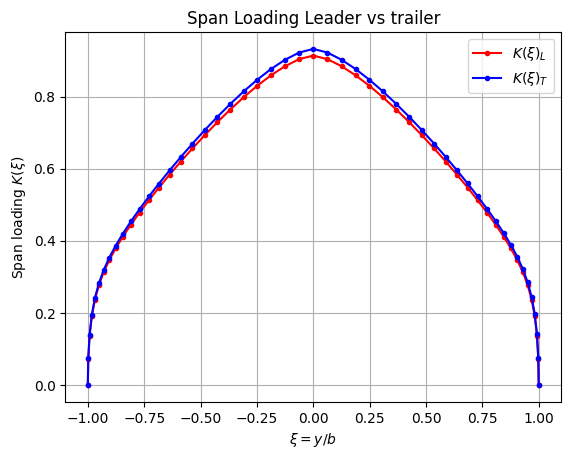

In [12]:
# ------------------------------------------------
# SPAN LOADING K(ξ)
# ------------------------------------------------
K2 = np.zeros(n)

for i in range(n):
    summation = 0.0
    for j in range(Nmodes2):
        summation += bn2[j] * np.sin(N2[j]*theta[i])
    K2[i] = 2 * AR * summation


### span loading
fig, ax = plt.subplots()

ax.plot(eta, K, '.-r', label=r'$K(\xi)_L$')
ax.plot(eta, K2, '.-b', label=r'$K(\xi)_T$')

ax.set_xlabel(r'$\xi = y/b$')
ax.set_ylabel(r'Span loading $K(\xi)$')
ax.set_title('Span Loading Leader vs trailer')
ax.grid(True)
ax.legend()

plt.show()


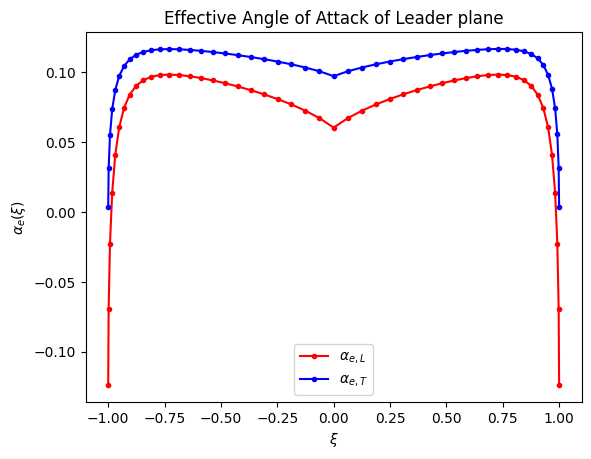

max |Downwash_angle_t| (deg): 7.369335066686897
max |induced_alpha_trailer| (deg): 0.27603655296373497
max |Gamma2| / (U_inf * b): 0.04459263197697814


In [13]:
#### Downwash for trailer (FIXED)

Downwash_angle_t = np.zeros(n)

for i in range(n):
    for j in range(Nmodes2):
        # 0.5 * N2[j] * bn2[j] * sin(N2[j]*theta[i]) / sin(theta[i])
        Downwash_angle_t[i] += 0.5 * N2[j] * bn2[j] * np.sin(N2[j] * theta[i]) / np.sin(theta[i])

# Effective AoA for trailer:
alpha_effe_tra = (alpha_wing_new_t + induced_alpha_trailer) - Downwash_angle_t


### alpha effective
fig, ax = plt.subplots()
ax.plot((eta),alpha_effective, ".-r", label='$\\alpha_{e,L}$')
ax.plot((eta),alpha_effe_tra, ".-b", label='$\\alpha_{e,T}$')
ax.set_xlabel('$\\xi$')
ax.set_ylabel('$\\alpha_e(\\xi)$')
ax.set_title('Effective Angle of Attack of Leader plane')
ax.legend()
plt.show()

print("max |Downwash_angle_t| (deg):", np.max(np.abs(np.rad2deg(Downwash_angle_t))))
print("max |induced_alpha_trailer| (deg):", np.max(np.abs(np.rad2deg(induced_alpha_trailer))))
print("max |Gamma2| / (U_inf * b):", np.max(np.abs(Gamma2 / (u_inf * b))))


In [14]:
# -----------------------------------------
# INDUCED DRAG OF TRAILER (FINAL)
# -----------------------------------------

d_theta = theta[1] - theta[0]

Drag_integral = 0.0
for i in range(n):
    Drag_integral += (
        Gamma2[i]
        * (Downwash_angle_t[i] - induced_alpha_trailer[i])
        * np.sin(theta[i])
        * d_theta
    )

drag_t = 0.5 * rho * u_inf * b * Drag_integral

CD_t = drag_t / (0.5 * rho * u_inf**2 * s)

print("Drag_t (N) =", drag_t)
print("CD_t      =", CD_t)


Drag_t (N) = 13957.966944028158
CD_t      = 0.01191072493764551


In [15]:
# ------------------------------------------------
# PART II.6: ROLLING MOMENT COEFFICIENT (Untrimmed Trailer)
# ------------------------------------------------
M_untrimmed = rho * u_inf * (b**2) / 4 * np.trapezoid(Gamma2 * np.cos(theta) * np.sin(theta), theta)
CM_untrimmed = M_untrimmed / (0.5 * rho * u_inf**2 * s * b)

print(f"Rolling moment M (untrimmed trailer) = {M_untrimmed:.1f} N.m")
print(f"Rolling moment coefficient C_M (untrimmed trailer) = {CM_untrimmed:.5f}")


Rolling moment M (untrimmed trailer) = 4966.0 N.m
Rolling moment coefficient C_M (untrimmed trailer) = 0.00012


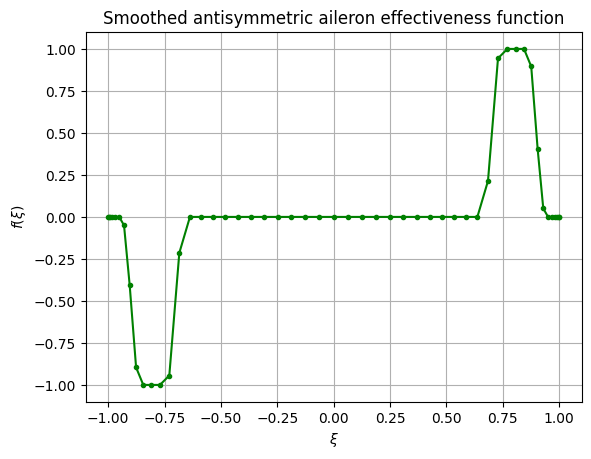

In [16]:
# ------------------------------------------------
# PART III.0: SMOOTHED AILERON EFFECTIVENESS FUNCTION f(xi)
# ------------------------------------------------
def H_eps(x, eps):
    """Regularized Heaviside function (see homework Appendix)."""
    xe = x / eps
    return np.where(xe < -1, 0.0,
           np.where(xe > 1, 1.0,
                    0.5 * (1 + xe + (1/np.pi) * np.sin(np.pi * xe))))

xi_lo, xi_hi = 0.70, 0.90   # aileron span: 0.70 <= |xi| <= 0.90
eps_ail = 0.05               # smoothing half-width in xi units (Appendix Fig. 2)

def aileron_bump(xi, lo, hi, eps):
    return H_eps(xi - lo, eps) - H_eps(xi - hi, eps)

# f(xi) = +1 on the xi>0 aileron, -1 on the mirrored xi<0 aileron (antisymmetric control law)
f_xi = aileron_bump(eta, xi_lo, xi_hi, eps_ail) - aileron_bump(-eta, xi_lo, xi_hi, eps_ail)

fig, ax = plt.subplots()
ax.plot(eta, f_xi, '.-g')
ax.set_xlabel(r'$\xi$')
ax.set_ylabel(r'$f(\xi)$')
ax.set_title('Smoothed antisymmetric aileron effectiveness function')
ax.grid(True)
plt.show()


alpha_w trailer (trimmed, deg) = 7.28  (unchanged from untrimmed)
Trim aileron deflection delta_a = -0.54 deg


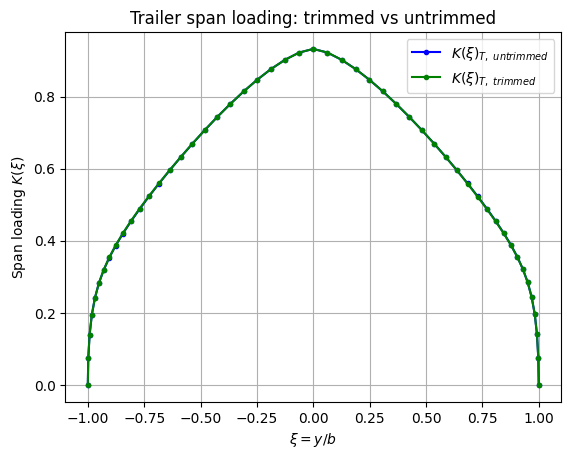

In [17]:
# ------------------------------------------------
# PART III.1-3: dn COEFFICIENTS AND TRIM AILERON DEFLECTION
# ------------------------------------------------
tau = 0.050   # aileron effectiveness factor (given)

B3 = (a0 * c / (2*b)) * f_xi
dn, *_ = np.linalg.lstsq(A2, B3, rcond=None)   # same wing matrix A2 as the untrimmed-trailer system

# circulation increment per unit (tau * delta_a)
Gamma_d = np.zeros(n)
for i in range(n):
    Gamma_d[i] = u_inf * b * np.sum(dn * np.sin(N2 * theta[i]))

# rolling moment increment per unit (tau * delta_a)
M_d = rho * u_inf * (b**2) / 4 * np.trapezoid(Gamma_d * np.cos(theta) * np.sin(theta), theta)

# angle of attack is unchanged from the untrimmed trailer (same CL requirement)
alpha_w_trailer_trim = alpha_wing_new_t

# trim condition: M_untrimmed + tau*delta_a*M_d = 0
tau_delta_a = -M_untrimmed / M_d
delta_a = tau_delta_a / tau

print(f"alpha_w trailer (trimmed, deg) = {np.rad2deg(alpha_w_trailer_trim):.2f}  (unchanged from untrimmed)")
print(f"Trim aileron deflection delta_a = {np.rad2deg(delta_a):.2f} deg")

# ------------------------------------------------
# TRIMMED CIRCULATION AND SPAN LOADING
# ------------------------------------------------
Gamma3 = Gamma2 + tau_delta_a * Gamma_d
K3 = (2 / (u_inf * c_mean)) * Gamma3

fig, ax = plt.subplots()
ax.plot(eta, K2, '.-b', label=r'$K(\xi)_{T,\ untrimmed}$')
ax.plot(eta, K3, '.-g', label=r'$K(\xi)_{T,\ trimmed}$')
ax.set_xlabel(r'$\xi = y/b$')
ax.set_ylabel(r'Span loading $K(\xi)$')
ax.set_title('Trailer span loading: trimmed vs untrimmed')
ax.grid(True)
ax.legend()
plt.show()


In [18]:
# ------------------------------------------------
# PART III.5: VERIFY TRIM AND INDUCED DRAG OF TRIMMED TRAILER
# ------------------------------------------------
M_trimmed = rho * u_inf * (b**2) / 4 * np.trapezoid(Gamma3 * np.cos(theta) * np.sin(theta), theta)
CM_trimmed = M_trimmed / (0.5 * rho * u_inf**2 * s * b)
print(f"Rolling moment coefficient C_M (trimmed) = {CM_trimmed:.2e}  (should be ~0)")

bn3 = bn2 + tau_delta_a * dn
Downwash_angle_trim = np.zeros(n)
for i in range(n):
    for j in range(Nmodes2):
        Downwash_angle_trim[i] += 0.5 * N2[j] * bn3[j] * np.sin(N2[j]*theta[i]) / np.sin(theta[i])

Drag_integral_trim = 0.0
for i in range(n):
    Drag_integral_trim += (
        Gamma3[i]
        * (Downwash_angle_trim[i] - induced_alpha_trailer[i])
        * np.sin(theta[i])
        * d_theta
    )
drag_t_trim = 0.5 * rho * u_inf * b * Drag_integral_trim
CD_t_trim = drag_t_trim / (0.5 * rho * u_inf**2 * s)

print(f"Drag_t trimmed (N)   = {drag_t_trim:.1f}")
print(f"CD_t trimmed         = {CD_t_trim:.5f}")
print(f"CD_t untrimmed       = {CD_t:.5f}")
print(f"CDi leader           = {CDi:.5f}")


Rolling moment coefficient C_M (trimmed) = 1.67e-18  (should be ~0)
Drag_t trimmed (N)   = 13958.0
CD_t trimmed         = 0.01191
CD_t untrimmed       = 0.01191
CDi leader           = 0.01327


In [19]:
# ------------------------------------------------
# PART III.6: TOTAL DRAG BENEFIT OF FORMATION FLIGHT
# ------------------------------------------------
CD0 = CDi  # parasitic drag assumed equal to the leader's induced drag coefficient (given)

CD_total_leader  = CD0 + CDi
CD_total_trailer = CD0 + CD_t_trim

drag_reduction_pct = 100 * (CD_total_leader - CD_total_trailer) / CD_total_leader

print(f"CD0 (parasitic, both aircraft) = {CD0:.5f}")
print(f"Total CD leader                = {CD_total_leader:.5f}")
print(f"Total CD trailer (trimmed)     = {CD_total_trailer:.5f}")
print(f"Trailer total-drag reduction   = {drag_reduction_pct:.1f} %")


CD0 (parasitic, both aircraft) = 0.01327
Total CD leader                = 0.02653
Total CD trailer (trimmed)     = 0.02518
Trailer total-drag reduction   = 5.1 %


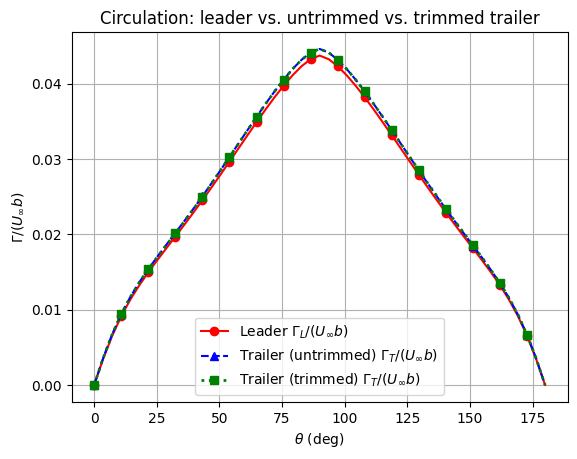

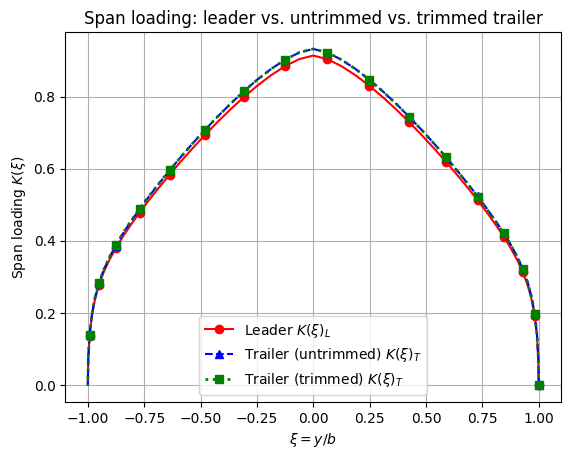

In [20]:
# ------------------------------------------------
# COMBINED FIGURES FOR REPORT: leader vs untrimmed trailer vs trimmed trailer,
# all three curves on the same axes (avoids redundant single-curve plots).
# ------------------------------------------------

fig, ax = plt.subplots()
ax.plot(np.rad2deg(theta), Gamma/(u_inf*b), 'r-', marker='o', markevery=3,
        label=r'Leader $\Gamma_L/(U_\infty b)$', linewidth=1.5)
ax.plot(np.rad2deg(theta), Gamma2/(u_inf*b), 'b--', marker='^', markevery=3,
        label=r'Trailer (untrimmed) $\Gamma_T/(U_\infty b)$', linewidth=1.5)
ax.plot(np.rad2deg(theta), Gamma3/(u_inf*b), 'g:', marker='s', markevery=3,
        label=r'Trailer (trimmed) $\Gamma_T/(U_\infty b)$', linewidth=2)
ax.set_xlabel(r'$\theta$ (deg)')
ax.set_ylabel(r'$\Gamma/(U_\infty b)$')
ax.set_title(r'Circulation: leader vs. untrimmed vs. trimmed trailer')
ax.grid(True)
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(eta, K, 'r-', marker='o', markevery=3, label=r'Leader $K(\xi)_L$', linewidth=1.5)
ax.plot(eta, K2, 'b--', marker='^', markevery=3, label=r'Trailer (untrimmed) $K(\xi)_T$', linewidth=1.5)
ax.plot(eta, K3, 'g:', marker='s', markevery=3, label=r'Trailer (trimmed) $K(\xi)_T$', linewidth=2)
ax.set_xlabel(r'$\xi = y/b$')
ax.set_ylabel(r'Span loading $K(\xi)$')
ax.set_title('Span loading: leader vs. untrimmed vs. trimmed trailer')
ax.grid(True)
ax.legend()
plt.show()
